# U3｜分類模型

> 單元三　|　主題：以「預測 2330 漲/跌方向」掌握分類器與評估，並處理不平衡資料

**單元目標**：從迴歸跨入分類，精熟五大分類器（Logistic、KNN、SVM、決策樹、Naive Bayes）、
混淆矩陣、ROC/AUC、Precision-Recall，並學會處理金融常見的**不平衡資料**（違約、詐欺）。

**學習目標**
1. 把 U2 的迴歸目標改成二元分類標籤（漲/跌），沿用同一組特徵與時序紀律。
2. 用 Logistic 迴歸輸出機率，理解 sigmoid 與決策閾值。
3. 用混淆矩陣拆解 precision / recall / F1，並用 ROC/PR 曲線評估。
4. 比較五大分類器，知道哪些需縮放、哪些可解釋。
5. 處理不平衡資料：`class_weight`、重抽樣概念、調整閾值。

---
> ⚠️ **誠實前提**：次日漲跌方向的可預測性同樣極低——accuracy 會接近 50%、AUC 接近 0.5。
> 這是正常的，重點仍是**方法論**。違約/詐欺資料使用合成（種子固定、明確標示）以確保離線可跑。

## Part 0｜分類問題設定與資料

In [15]:
# !pip install ta-lib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import talib
np.random.seed(42)

In [ ]:
df = yf.download('2327.TW', start='2000-01-01', end='2026-07-15', auto_adjust=True, progress=False)
df.columns = [c[0] if isinstance(c, tuple) else c for c in df.columns]
df

### 📖 白話版：什麼是分類，跟迴歸差在哪

**一句話：U2 在猜「數字」，U3 在猜「類別」。**

想像兩種考題：
- **迴歸（U2）**：「明天會漲跌**幾趴**？」——答案是一個**數字**（+0.8%、−1.2%…），可以有無限多種。
- **分類（U3）**：「明天是**漲還是跌**？」——答案只有**兩種選項**（漲／跌），像是非題。

U3 做的事很簡單：把 U2 那個「明天報酬率」的數字，**用 0 當分界線，轉成一個標籤**：

> 報酬 > 0 → 貼上 `1`（漲）　　報酬 ≤ 0 → 貼上 `0`（跌）

**為什麼故意沿用 U2 的資料和特徵？**
因為這樣不用重學資料前處理，可以把全部注意力放在「分類」這件新事情上。
同一支 2330、同一組技術指標，只是把「要猜的答案」從數字換成漲跌標籤而已。

**Part 0 最後為什麼要看「類別分布」？**
因為分類問題有個迴歸沒有的隱藏陷阱——**類別會不會失衡**。
2330 的漲跌大約是 50/50（平衡），先確認這件事，是為了替後面 Part 4 的「不平衡資料」埋伏筆：
當你遇到「99% 沒違約、1% 違約」這種**極度失衡**的資料時，很多直覺都會失效。

In [ ]:
# 計算當日的報酬率
df['ret'] = df['Close'].pct_change(fill_method=None)

# 利用當日的報酬率產生次日的報酬率並轉換為分類標籤0跟1，0代表跌，1代表漲
df['target'] = df['ret'].shift(-1)
df['target_class'] = (df['ret'].shift(-1) > 0).astype(int)
df.tail()

# 產生用來預測的10個技術指標特徵
H, L, C, V = df['High'], df['Low'], df['Close'], df['Volume']
df['rsi14'] = talib.RSI(C, 14)
df['macd_hist'] = talib.MACD(C, 12, 26, 9)[2]
df['stoch_k'] = talib.STOCH(H, L, C, 14, 3, 0, 3, 0)[0]
df['willr'] = talib.WILLR(H, L, C, 14)
df['cci'] = talib.CCI(H, L, C, 14)
df['adx'] = talib.ADX(H, L, C, 14)
df['atr_pct'] = talib.ATR(H, L, C, 14) / C
up, mid, lo = talib.BBANDS(C, 20, 2, 2)
df['bb_pcb'] = (C - lo) / (up - lo)
df['roc10'] = talib.ROC(C, 10)
df['vol_ratio'] = V / talib.SMA(V, 20) - 1
data = df.dropna().copy()
data

In [23]:
# 分類任務的第一步:先看預測目標物是否平衡
# value_counts() 檢查各個類別有幾筆資料
# value_counts(normalize=True) 回傳比例，而不是筆數
data['target_class'].value_counts(normalize=True).round(3)

,proportion
target_class,
0,0.545
1,0.455


### 📖 白話版：Logistic 迴歸——把「分數」翻譯成「機率」

**核心問題**：線性迴歸算出來的是一個可大可小的數字（可能是 −5、也可能是 +37），
但「漲的機率」必須介於 0 到 100% 之間。**怎麼把前者變成後者？**

答案就是 **sigmoid** 這個「壓縮函數」，你可以把它想成一台**翻譯機**：

> 不管你丟進去的分數多大多小（−∞ 到 +∞），它都會**擠壓成一個 0~1 之間的數字**，
> 讓我們能當成「漲的機率」來讀。

- 分數很大的正數 → 擠到接近 **1**（幾乎確定漲）
- 分數很大的負數 → 擠到接近 **0**（幾乎確定跌）
- 分數剛好 0 → 對到 **0.5**（五五波）

所以 **Logistic 迴歸 = 線性迴歸算一個分數 → sigmoid 把分數翻譯成機率**。
它本質上還是「加權特徵」那一套，只是最後多包一層翻譯機，讓輸出變成「漲的機率」而非一個沒界限的數字。

---

**① `predict` vs `predict_proba`——兩種不同的輸出**
- `predict` 給你**最終答案**：0 或 1（跌或漲）。
- `predict_proba` 給你**信心程度**：例如「跌的機率 0.48、漲的機率 0.52」。

差別在哪？`predict` 其實是拿 `predict_proba` 的機率、用 **0.5 當及格線**轉出來的：
機率 ≥ 0.5 就判「漲」，否則「跌」。

> **為什麼機率那麼重要？** 因為「0.51 判漲」和「0.95 判漲」在 `predict` 眼裡都只是「漲」，
> 但它們的**把握天差地遠**。保留機率，你才能做後面 Part 2 的兩件事：
> 畫 ROC 曲線、以及**調整那條 0.5 的及格線**（正是練習 1.1 在玩的）。

**② 係數 → odds——哪個指標在幫「漲」講話**
跟 U2 的迴歸係數一樣的讀法：**正係數 = 這個指標越大、越傾向判漲；負係數 = 越傾向判跌**。
看哪個特徵的係數絕對值大，就知道模型最看重哪個指標。
（一樣要記得：因為包了 `StandardScaler`，係數才站在同一個尺度上、可以互相比。）



In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

feat = ['rsi14', 'macd_hist', 'stoch_k', 'willr', 'cci', 'adx', 'atr_pct',
      'bb_pcb', 'roc10', 'vol_ratio']
X, y = data[feat], data['target_class']

# 用日期的方式進行資料的切分
split_date = '2023-01-01'
train = data.index < split_date
test = data.index >= split_date
X, y = data[feat], data['target_class']
X_train, X_test = X[train], X[test]
y_train, y_test = y[train], y[test]

# 使用80/20法則來進行資料的切分
split = int(len(data) * 0.8)
X_train_8020, X_test_8020 = X.iloc[:split], X.iloc[split:]
y_train_8020, y_test_8020 = y.iloc[:split], y.iloc[split:]

print(f'使用日期的切分日 {split_date}')
print(f'使用日期的訓練集 {len(X_train)} 筆 {X_train.index.min().date()} ~ {X_train.index.max().date()}' )
print(f'使用日期的測試集 {len(X_test)} 筆 {X_test.index.min().date()} ~ {X_test.index.max().date()}')

print(f'使用80/20的切分日 {split} 筆')
print(f'使用80/20的訓練集 {len(X_train_8020)} 筆 {X_train_8020.index.min().date()} ~ {X_train_8020.index.max().date()}' )
print(f'使用80/20的測試集 {len(X_test_8020)} 筆 {X_test_8020.index.min().date()} ~ {X_test_8020.index.max().date()}')

# 進行模型的準備+訓練+測試
clf = make_pipeline(StandardScaler(), LogisticRegression()).fit(X_train, y_train)
print(f'Logistic 測試集的 Accuracy: {clf.score(X_test, y_test):.3f}')

使用日期的切分日 2023-01-01
使用日期的訓練集 5713 筆 2000-02-18 ~ 2022-12-30
使用日期的測試集 848 筆 2023-01-03 ~ 2026-07-13
使用80/20的切分日 5248 筆
使用80/20的訓練集 5248 筆 2000-02-18 ~ 2021-02-04
使用80/20的測試集 1313 筆 2021-02-05 ~ 2026-07-13
Logistic 測試集的 Accuracy: 0.509


In [45]:
# 分類器有兩種輸出
# predict，他是會直接給0/1，他判斷的標準是用0.5作為門檻，所以只要>=0.5，就判斷為1，反之就是0
# predict_proba，他是會直接給機率，所以他會回傳兩個欄位，第1欄是跌的機率，第2欄是漲的機率

print(f'predict: {clf.predict(X_test)[:5]}')
print(f'predict_proba: {clf.predict_proba(X_test)[:5].round(3)}')

pred = clf.predict(X_test)
proba = clf.predict_proba(X_test)[:, 1]

compare = pd.DataFrame({'實際':y_test.values,
            '預測':pred,
            'P(漲)':proba.round(3),
            '結果':np.where(y_test.values == pred, '對', '錯')}, index=X_test.index)
compare

predict: [0 0 0 0 0]
predict_proba: [[0.586 0.414]
 [0.569 0.431]
 [0.578 0.422]
 [0.529 0.471]
 [0.506 0.494]]


,實際,預測,P(漲),結果
Date,,,,
2023-01-03,0,0,0.414,對
2023-01-04,1,0,0.431,錯
2023-01-05,1,0,0.422,錯
2023-01-06,1,0,0.471,錯
2023-01-09,1,0,0.494,錯
...,...,...,...,...
2026-07-07,0,0,0.369,對
2026-07-08,1,0,0.294,錯
2026-07-09,0,0,0.302,對


### 📖 白話版：為什麼 accuracy 不夠，該看什麼

**先講一個 accuracy 騙人的故事**
假設有支股票 95% 的日子都在漲。你做一個「無腦模型」——不管三七二十一**每天都猜漲**。
它的 accuracy 是多少？**95%**！看起來超神，但它其實什麼都沒學到，
遇到「跌」的日子全部答錯。這就是為什麼**光看 accuracy 會被騙**——
它會被「多數的那一類」灌水（這正是練習 0.1 的重點）。

所以我們需要一個工具，把模型「**對在哪、錯在哪**」拆開來看。

---

### 混淆矩陣：把對錯拆成四格
混淆矩陣就是一張 2×2 的成績單，把「真實答案 × 模型判斷」的組合分成四格：

| | 模型判「漲」 | 模型判「跌」 |
|---|---|---|
| **真的漲** | ✅ TP（抓對了） | ❌ FN（漏抓，真漲卻說跌） |
| **真的跌** | ❌ FP（誤報，真跌卻說漲） | ✅ TN（躲對了） |

記法：**T/F = 有沒有猜對，P/N = 模型猜漲(P)還是跌(N)**。
兩種錯誤有名字很重要：**FP=誤報（狼來了）、FN=漏抓（該喊沒喊）**——它們的代價常常不一樣（下面會講）。

### 從四格算出兩個關鍵指標
- **Precision（精確率）＝「判漲的裡面，有幾個真的漲」**
  → 模型喊漲時**可不可信**。喊 100 次漲、80 次真的漲，precision=80%。
- **Recall（召回率）＝「所有真的漲，被抓回來幾個」**
  → 真的機會**有沒有被漏掉**。100 個真漲、抓回 60 個，recall=60%。

> 一句話記憶：**Precision 是「你喊的準不準」，Recall 是「該抓的漏沒漏」。**
> 這兩個通常是**蹺蹺板**——想更準（precision↑）就會變得更保守、漏更多（recall↓），反之亦然。
> `F1` 就是兩者的綜合平衡分數。

---

### 💰 為什麼要在乎這兩個：兩種錯誤的代價不一樣
在很多真實場景，**FP 和 FN 的代價天差地遠**。以**違約預測**為例：
- **FN（把壞戶當成好戶放款）** → 錢借出去收不回，**慘賠**。
- **FP（把好戶誤判成壞戶拒貸）** → 只是少賺一筆利息，**損失有限**。

既然「漏抓壞戶」比「誤殺好戶」貴太多，風控實務就會**寧可錯殺、不可放過**——
刻意犧牲一點 precision，把 recall 拉高。**這就是為什麼不能只看一個總分，要看你在乎哪種錯誤。**

---

### 那條 0.5 的線，就是控制蹺蹺板的旋鈕
還記得 Part 1 說「判漲的 0.5 及格線可以動」嗎？**移動它，就是在 precision 和 recall 之間取捨**（cell 20 在示範）：
- 門檻**調高**（如 0.55）→ 要更有把握才喊漲 → 喊得少但準（**precision↑、recall↓**）。
- 門檻**調低**（如 0.45）→ 寧可多喊 → 抓得多但雜（**recall↑、precision↓**）。

你要把旋鈕轉去哪，取決於上面那個「哪種錯誤比較貴」。

### ROC 與 PR 曲線：一次看完「所有門檻」的表現
單一門檻只是一個點。**ROC 曲線和 PR 曲線是把「所有可能門檻」的表現連成一條線**，讓你一眼看完模型整體有多強：
- **AUC**（ROC 曲線下面積）：**0.5 = 跟丟銅板一樣爛、1.0 = 完美**。這是最常用的「一個數字看模型整體實力」。
- **PR 曲線**：在**不平衡資料**上比 ROC **更誠實**——因為它專注在「少數類抓得好不好」，不會被大量的多數類灌水（Part 4 會具體對比）。

> **本節心法**：不平衡時，別再只報 accuracy。先看混淆矩陣拆解對錯，
> 再依「哪種錯誤比較貴」選 precision 或 recall，最後用 AUC / PR 曲線看整體。

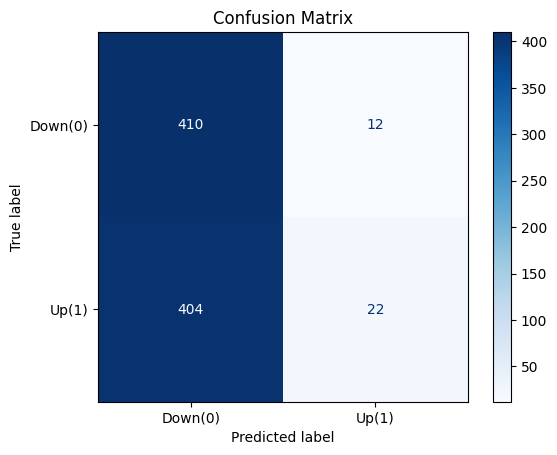

In [51]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Down(0)', 'Up(1)']).plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [55]:
from sklearn.metrics import classification_report
# classification_report:一次列出每個類別的4個指標
# precision(精確率)是判斷該類，真的是該類的指標
# recall(召回率)是判斷真的是該類中，被抓回來的比例
# F1-Score是precision和recall的調和平均數
# support是該類別的實際樣本數

print(classification_report(y_test, y_pred, target_names=['跌', '漲'], zero_division=0))

              precision    recall  f1-score   support

           跌       0.50      0.97      0.66       422
           漲       0.65      0.05      0.10       426

    accuracy                           0.51       848
   macro avg       0.58      0.51      0.38       848
weighted avg       0.58      0.51      0.38       848



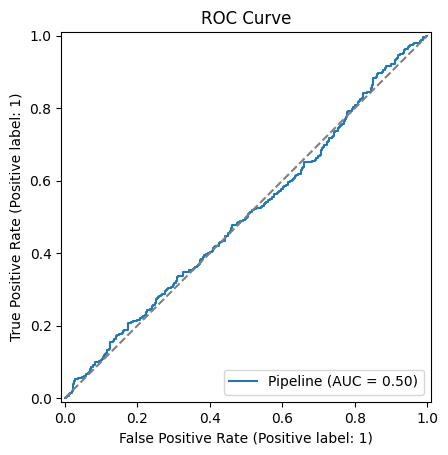

AUC: 0.504


In [60]:
# ROC曲線與AUC
# 曲線越往左上角靠，代表分類能力越好
from sklearn.metrics import roc_auc_score, RocCurveDisplay

RocCurveDisplay.from_estimator(clf, X_test, y_test) # 直接從模型+測試資料畫ROC
plt.plot([0, 1], [0, 1], '--', color='gray') # 畫出對角線，也就是隨機亂猜的基準線
plt.title('ROC Curve')
plt.show()
# AUC = ROC曲線的下面積:0.5代表亂猜，1.0代表完美，追求接近1.0
print(f'AUC: {roc_auc_score(y_test, proba):.3f}')

In [63]:
# KNN分類器(K最近鄰):看距離最近的K個鄰居，然後用多數投票的方式來決定類別
# n_neghbors = 15，代表參考最近的15個鄰居
# 距離型的模型對特徵的數值大小非常敏感，所以必須要做特徵縮放的動作
from sklearn.neighbors import KNeighborsClassifier
knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=15)).fit(X_train, y_train)
print(f'KNN Accuracy: {knn.score(X_test, y_test):.3f}')

KNN Accuracy: 0.487


In [70]:
# 支持向量機分類器
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV # 機率校準器
# SVM:其實就是在特徵空間裡面去找出一條可以最大化特徵點距離的決策邊界
# kernel = 'rbf':用RBF核心去找彎曲的決策邊界
# C=1: 懲罰係數，C如果設定的越大，則越貼合訓練資料，越容易過擬和
# SVM也是屬於距離型的模型，所以一樣都需要經過資料標準化
svm = make_pipeline(StandardScaler(), CalibratedClassifierCV(SVC(kernel='rbf', C=1), ensemble=False)) \
    .fit(X_train, y_train)

print(f'SVM Accuracy: {svm.score(X_test, y_test):.3f}')

SVM Accuracy: 0.488


In [73]:
from sklearn.tree import DecisionTreeClassifier
# 決策樹:靠一連串的if條件把資料逐層的切分做決策
# max_depth = 3: 限制樹最多長3層，避免過度細分而過擬合
# random_state=42: 固定隨機性，讓結果可以重現
# 樹模型不需要進行特徵縮放

tree = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_train, y_train)
print(f'Tree Accuracy: {tree.score(X_test, y_test):.3f}')

Tree Accuracy: 0.482


In [76]:
# Naive Bayes 樸素貝式網路:用貝式定理算出屬於各類別的機率
# 優點:訓練極快，因為只需要估平均數與變異數
from sklearn.naive_bayes import GaussianNB
nb = make_pipeline(StandardScaler(), GaussianNB()).fit(X_train, y_train)
print(f'NB Accuracy: {nb.score(X_test, y_test):.3f}')

NB Accuracy: 0.499


## 綜合：玉山金（2884）次日漲跌方向預測（分類版）

用**玉山金（2884）**日線資料預測**次日漲跌方向**（漲/跌），把 U3 學到的分類器全部用上，
最後產出各模型的 **accuracy / AUC 對照表**，並誠實判讀。

### 具體要求

1. **資料**：抓 2884 玉山金，區間 **2015-01-01 ~ 2026-07-13**（還原價）。
2. **目標**：`target = 次日漲跌`——次日報酬 > 0 標 `1`（漲）、否則 `0`（跌）。
3. **特徵**：用 **talib 產生 10 個技術指標**（全部只用過去資料，無 look-ahead）。指定這 10 個：
   `rsi14`、`macd_hist`、`stoch_k`、`willr`、`cci`、`adx`、`atr_pct`、`bb_pctb`、`roc10`、`vol_ratio`。
4. **切分**：用**70/30**切分——`split = int(len(data)*0.7)`，該日之前訓練、之後測試，**不可隨機 shuffle**。
5. **模型**：跑本章五個分類器——`Logistic`、`KNN`、`SVM`、`決策樹`、`Naive Bayes`
   （需縮放的包 `StandardScaler`；**決策樹不縮放**）。用 accuracy / AUC 對照表比較，
   選出最佳後、**只對最佳模型畫混淆矩陣**。
6. **輸出**：各模型的 accuracy / AUC 對照表 ＋ **最佳模型**的混淆矩陣與 `classification_report`。
7. **結論**：3–5 行誠實討論——有沒有模型明顯贏過多數類基準？AUC 離 0.5 遠不遠？
   當每個模型都跟亂猜差不多時，「選出的最佳」還有意義嗎？這代表什麼？

In [90]:
# !pip install ta-lib

import numpy as np
import pandas as pd
import yfinance as yf
import talib

from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score

# 1. 使用yfinance抓取玉山金的資料(2015-01-01~2026-07-13，不含除權息的股價)
df = yf.download('2884.TW', start='2015-01-01', end='2026-07-14', auto_adjust=True, progress=False)
df.columns = [c[0] if isinstance(c, tuple) else c for c in df.columns]
df

# 2. 設立目標:次日報酬率(漲跌)
# df['target'] = df['ret'].shift(-1)
df['ret'] = df['Close'].pct_change(fill_method=None)
df['target'] = (df['ret'].shift(-1) > 0).astype(int)
df.tail()

# 3. 使用talib產生10個特徵
H, L, C, V = df['High'], df['Low'], df['Close'], df['Volume']
df['rsi14'] = talib.RSI(C, 14)
df['macd_hist'] = talib.MACD(C, 12, 26, 9)[2]
df['stoch_k'] = talib.STOCH(H, L, C, 14, 3, 0, 3, 0)[0]
df['willr'] = talib.WILLR(H, L, C, 14)
df['cci'] = talib.CCI(H, L, C, 14)
df['adx'] = talib.ADX(H, L, C, 14)
df['atr_pct'] = talib.ATR(H, L, C, 14) / C
up, mid, lo = talib.BBANDS(C, 20, 2, 2)
df['bb_pcb'] = (C - lo) / (up - lo)
df['roc10'] = talib.ROC(C, 10)
df['vol_ratio'] = V / talib.SMA(V, 20) - 1

feat = ['rsi14', 'macd_hist', 'stoch_k', 'willr', 'cci', 'adx', 'atr_pct',
      'bb_pcb', 'roc10', 'vol_ratio']
data = df.dropna().copy()
data

# 4. 用70/30切分訓練集和測試集
split = int(len(data) * 0.7)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f'使用70/30的切分日 {split} 筆')
print(f'使用70/30的訓練集 {len(X_train)} 筆 {X_train.index.min().date()} ~ {X_train.index.max().date()}' )
print(f'使用70/30的測試集 {len(X_test)} 筆 {X_test.index.min().date()} ~ {X_test.index.max().date()}')

models = {'Logisitc':make_pipeline(StandardScaler(), LogisticRegression()),
      'KNN':make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=15)),
      'SVM':make_pipeline(StandardScaler(), SVC(kernel='rbf', probability=True)),
      'Tree':DecisionTreeClassifier(max_depth=3, random_state=42),
      'NB':make_pipeline(StandardScaler(), GaussianNB())}
models
results= []
for name, m in models.items():
  m.fit(X_train, y_train)
  acc = accuracy_score(y_test, m.predict(X_test))
  auc = roc_auc_score(y_test, m.predict_proba(X_test)[:, 1])
  results.append((name, acc, auc))

table = pd.DataFrame(results, columns=['模型', '測試acc', '測試auc']).set_index('模型')
table

使用70/30的切分日 1937 筆
使用70/30的訓練集 1937 筆 2015-03-02 ~ 2023-02-06
使用70/30的測試集 831 筆 2023-02-07 ~ 2026-07-13


,測試acc,測試auc
模型,,
Logisitc,0.501805,0.515218
KNN,0.521059,0.532301
SVM,0.512635,0.485049
Tree,0.505415,0.493098
NB,0.503008,0.494798
